<a href="https://colab.research.google.com/github/Crisjaratto/deep-learning-2-TdeA/blob/main/Guia_02_Redes_Neuronales_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import time
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


In [4]:
print(f"Version de TensorFlow: {tf.__version__}")
print(f"Version de Keras: {keras.__version__}")
print(f"Version de NumPy: {np.__version__}")

# Verificar si hay GPU disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\nGPU disponible: {gpus}")
    print("El entrenamiento sera mas rapido con GPU.")
else:
    print("\nNo se detecto GPU. Se usara CPU.")
    print("Esto es normal si estas en tu computador ")

Version de TensorFlow: 2.19.0
Version de Keras: 3.10.0
Version de NumPy: 2.0.2

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
El entrenamiento sera mas rapido con GPU.


In [5]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Semilla de reproducibilidad fijada en: {SEED}")
print("Esto garantiza que los resultados sean consistentes entre ejecuciones.")

Semilla de reproducibilidad fijada en: 42
Esto garantiza que los resultados sean consistentes entre ejecuciones.


In [6]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

print("Dataset MNIST cargado exitosamente!")
print(f"\n--- Conjunto de entrenamiento ---")
print(f"  Imagenes (x_train): {x_train_raw.shape}")
print(f"  Etiquetas (y_train): {y_train_raw.shape}")
print(f"\n--- Conjunto de prueba ---")
print(f"  Imagenes (x_test): {x_test_raw.shape}")
print(f"  Etiquetas (y_test): {y_test_raw.shape}")
print(f"\n--- Informacion adicional ---")
print(f"  Tipo de datos de las imagenes: {x_train_raw.dtype}")
print(f"  Valor minimo de un pixel: {x_train_raw.min()}")
print(f"  Valor maximo de un pixel: {x_train_raw.max()}")
print(f"  Clases unicas: {np.unique(y_train_raw)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset MNIST cargado exitosamente!

--- Conjunto de entrenamiento ---
  Imagenes (x_train): (60000, 28, 28)
  Etiquetas (y_train): (60000,)

--- Conjunto de prueba ---
  Imagenes (x_test): (10000, 28, 28)
  Etiquetas (y_test): (10000,)

--- Informacion adicional ---
  Tipo de datos de las imagenes: uint8
  Valor minimo de un pixel: 0
  Valor maximo de un pixel: 255
  Clases unicas: [0 1 2 3 4 5 6 7 8 9]


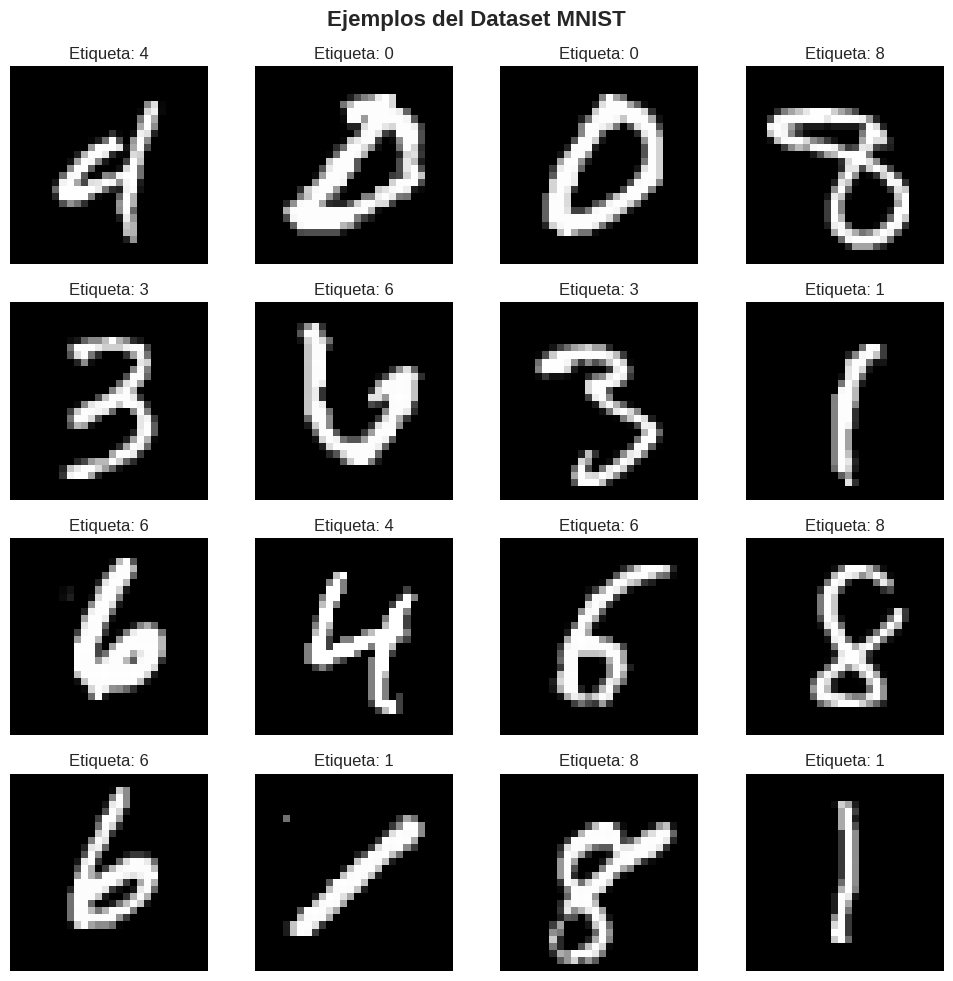

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Ejemplos del Dataset MNIST', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Seleccionamos un indice aleatorio
    idx = np.random.randint(0, len(x_train_raw))
    ax.imshow(x_train_raw[idx], cmap='gray')
    ax.set_title(f'Etiqueta: {y_train_raw[idx]}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

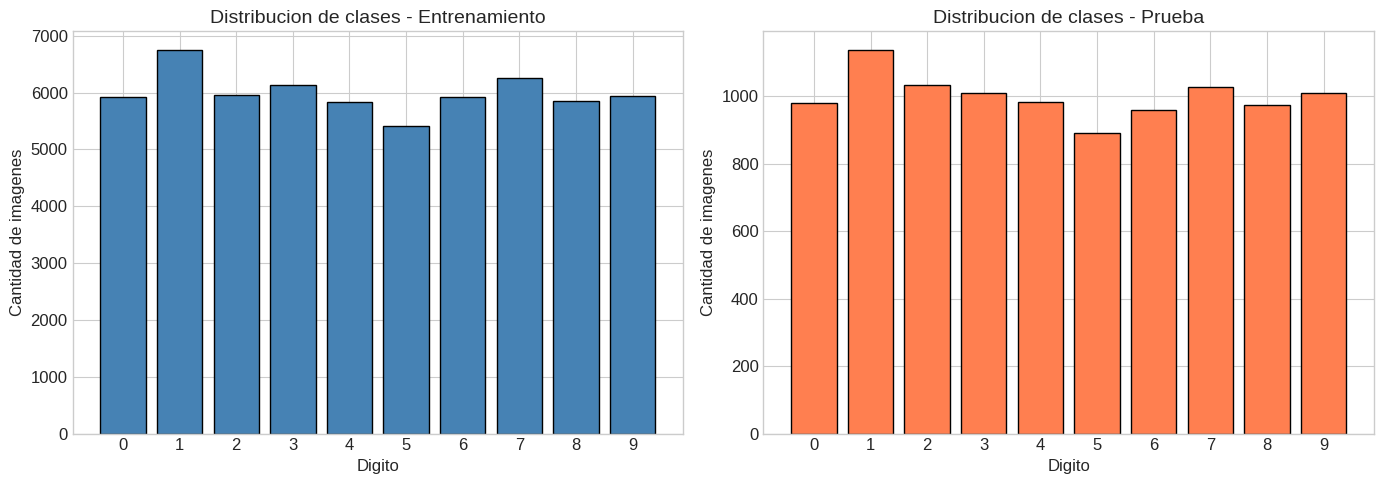

Las clases estan razonablemente balanceadas.
Rango de imagenes por clase (train): 5421 - 6742


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucion en entrenamiento
clases_train, conteos_train = np.unique(y_train_raw, return_counts=True)
axes[0].bar(clases_train, conteos_train, color='steelblue', edgecolor='black')
axes[0].set_title('Distribucion de clases - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Digito')
axes[0].set_ylabel('Cantidad de imagenes')
axes[0].set_xticks(range(10))

# Distribucion en prueba
clases_test, conteos_test = np.unique(y_test_raw, return_counts=True)
axes[1].bar(clases_test, conteos_test, color='coral', edgecolor='black')
axes[1].set_title('Distribucion de clases - Prueba', fontsize=14)
axes[1].set_xlabel('Digito')
axes[1].set_ylabel('Cantidad de imagenes')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

print("Las clases estan razonablemente balanceadas.")
print(f"Rango de imagenes por clase (train): {conteos_train.min()} - {conteos_train.max()}")

In [9]:
x_train_norm = x_train_raw.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

print("--- Despues de la normalizacion ---")
print(f"Tipo de dato: {x_train_norm.dtype}")
print(f"Valor minimo: {x_train_norm.min()}")
print(f"Valor maximo: {x_train_norm.max()}")

# --- Paso 2: Reshape (aplanar de 28x28 a 784)
x_train = x_train_norm.reshape(-1, 784)  # -1 significa "calcula esta dimension automaticamente"
x_test = x_test_norm.reshape(-1, 784)

print(f"\n--- Despues del reshape ---")
print(f"Forma de x_train: {x_train.shape}  (60000 imagenes, cada una con 784 pixeles)")
print(f"Forma de x_test: {x_test.shape}")

num_clases = 10
y_train = to_categorical(y_train_raw, num_clases)
y_test = to_categorical(y_test_raw, num_clases)

print(f"\n--- Despues del one-hot encoding ---")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")
print(f"\nEjemplo - Digito {y_train_raw[0]}:")
print(f"  Etiqueta original: {y_train_raw[0]}")
print(f"  One-hot encoding:  {y_train[0]}")

--- Despues de la normalizacion ---
Tipo de dato: float32
Valor minimo: 0.0
Valor maximo: 1.0

--- Despues del reshape ---
Forma de x_train: (60000, 784)  (60000 imagenes, cada una con 784 pixeles)
Forma de x_test: (10000, 784)

--- Despues del one-hot encoding ---
Forma de y_train: (60000, 10)
Forma de y_test: (10000, 10)

Ejemplo - Digito 5:
  Etiqueta original: 5
  One-hot encoding:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [10]:
# --- Paso 1: Definir la arquitectura ---
# Usamos la API Sequential: las capas se apilan una tras otra.

modelo_1 = keras.Sequential([
    # Capa oculta: 128 neuronas, activacion ReLU
    # input_shape=(784,) le dice a Keras el tamano de la entrada
    layers.Dense(128, activation='relu', input_shape=(784,), name='capa_oculta'),

    # Capa de salida: 10 neuronas (una por clase), activacion Softmax
    # Softmax convierte las salidas en probabilidades que suman 1
    layers.Dense(10, activation='softmax', name='capa_salida')
], name='Mi_Primera_Red')

print("Modelo creado exitosamente!")
print("="*60)

Modelo creado exitosamente!


In [11]:
# --- Paso 2: Ver el resumen del modelo ---
# model.summary() nos muestra:
# - Nombre de cada capa
# - Forma de salida de cada capa
# - Numero de parametros (pesos + sesgos) por capa

modelo_1.summary()

# Desglose de parametros:
# Capa oculta: 784 entradas * 128 neuronas + 128 sesgos = 100,480 parametros
# Capa salida: 128 entradas * 10 neuronas + 10 sesgos = 1,290 parametros
# Total: 101,770 parametros
print(f"\nTotal de parametros entrenables: {modelo_1.count_params():,}")


Model: "Mi_Primera_Red"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)             │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Total de parametros entrenables: 101,770


In [12]:
# --- Paso 3: Compilar el modelo ---
# Compilar = configurar COMO el modelo va a aprender.
# Necesitamos especificar:
#   - optimizer: algoritmo de optimizacion (como actualizar los pesos)
#   - loss: funcion de perdida (como medir el error)
#   - metrics: metricas adicionales para monitorear

modelo_1.compile(
    optimizer='adam',                       # Optimizador Adam (adaptativo, buena opcion general)
    loss='categorical_crossentropy',        # Funcion de perdida para clasificacion multiclase
    metrics=['accuracy']                    # Queremos ver la precision durante el entrenamiento
)

print("Modelo compilado exitosamente!")
print("  Optimizador: Adam")
print("  Funcion de perdida: Categorical Cross-Entropy")
print("  Metrica: Accuracy (Precision)")

Modelo compilado exitosamente!
  Optimizador: Adam
  Funcion de perdida: Categorical Cross-Entropy
  Metrica: Accuracy (Precision)


In [13]:
# --- Paso 4: Entrenar el modelo ---
# model.fit() entrena la red. Los parametros principales son:
#   - x, y: datos de entrada y etiquetas
#   - epochs: cuantas veces recorrer todo el dataset
#   - batch_size: cuantas imagenes procesar a la vez
#   - validation_split: porcentaje de datos para validacion
#   - verbose: nivel de detalle en la salida (1 = barra de progreso)

print("Iniciando entrenamiento...")
print("="*60)

historial_1 = modelo_1.fit(
    x_train, y_train,           # Datos de entrenamiento
    epochs=10,                   # 10 pasadas completas por el dataset
    batch_size=128,              # Procesar 128 imagenes por paso
    validation_split=0.2,        # Usar 20% para validacion (12,000 imagenes)
    verbose=1                    # Mostrar progreso
)

print("\nEntrenamiento completado!")

Iniciando entrenamiento...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8111 - loss: 0.6777 - val_accuracy: 0.9410 - val_loss: 0.2124
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9418 - loss: 0.2047 - val_accuracy: 0.9537 - val_loss: 0.1567
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9592 - loss: 0.1431 - val_accuracy: 0.9613 - val_loss: 0.1294
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9691 - loss: 0.1088 - val_accuracy: 0.9664 - val_loss: 0.1142
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9753 - loss: 0.0872 - val_accuracy: 0.9682 - val_loss: 0.1053
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9799 - loss: 0.0716 - val_accuracy: 0.9706 - val_loss: 0.0993
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9838 - loss: 0.0599 - val_accuracy: 0.9720 - val_loss: 0.0952
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9870 - loss

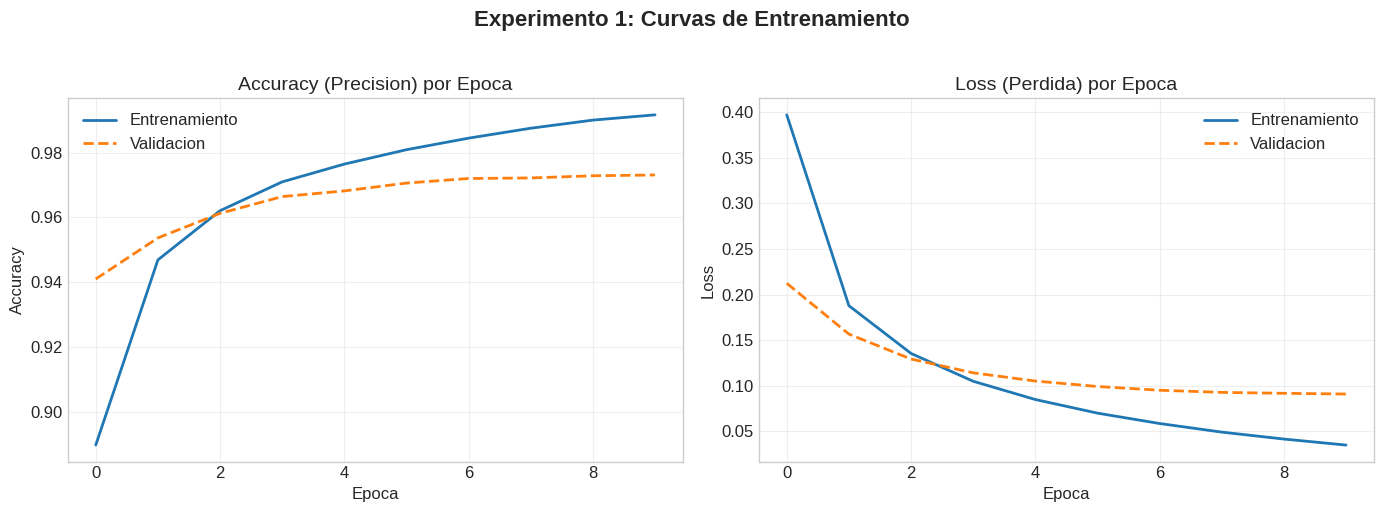

In [14]:
# --- Paso 5: Graficar las curvas de entrenamiento ---
# Estas curvas son FUNDAMENTALES para diagnosticar el comportamiento del modelo.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica de Accuracy
axes[0].plot(historial_1.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[0].plot(historial_1.history['val_accuracy'], label='Validacion', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy (Precision) por Epoca', fontsize=14)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Grafica de Loss
axes[1].plot(historial_1.history['loss'], label='Entrenamiento', linewidth=2)
axes[1].plot(historial_1.history['val_loss'], label='Validacion', linewidth=2, linestyle='--')
axes[1].set_title('Loss (Perdida) por Epoca', fontsize=14)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Experimento 1: Curvas de Entrenamiento', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [15]:
# --- Paso 6: Evaluar en el conjunto de prueba ---
# IMPORTANTE: El conjunto de prueba NUNCA se usa durante el entrenamiento.
# Es la medida final y objetiva del rendimiento del modelo.

loss_test, accuracy_test = modelo_1.evaluate(x_test, y_test, verbose=0)

print("="*60)
print("RESULTADOS EN EL CONJUNTO DE PRUEBA")
print("="*60)
print(f"  Loss (perdida):     {loss_test:.4f}")
print(f"  Accuracy (precision): {accuracy_test:.4f}  ({accuracy_test*100:.2f}%)")
print("="*60)
print(f"\nTu primera red neuronal clasifica correctamente el {accuracy_test*100:.2f}% de los digitos!")

RESULTADOS EN EL CONJUNTO DE PRUEBA
  Loss (perdida):     0.0825
  Accuracy (precision): 0.9747  (97.47%)

Tu primera red neuronal clasifica correctamente el 97.47% de los digitos!


In [16]:
# ============================================================
# EXPERIMENTO 2: Efecto del numero de capas ocultas
# ============================================================

# Funcion auxiliar para crear, compilar, entrenar y evaluar un modelo.
# Esto evita repetir codigo y nos permite experimentar facilmente.

def crear_y_entrenar_modelo(capas_ocultas, nombre, epochs=10, verbose=0):
    """
    Crea, compila, entrena y evalua un modelo con la configuracion dada.

    Parametros:
    - capas_ocultas: lista de tuplas (neuronas, activacion) para cada capa oculta
    - nombre: nombre del modelo
    - epochs: numero de epocas de entrenamiento
    - verbose: nivel de detalle de la salida

    Retorna:
    - modelo entrenado, historial de entrenamiento, tiempo de entrenamiento
    """
    # Crear modelo
    modelo = keras.Sequential(name=nombre)

    # Primera capa oculta (necesita input_shape)
    modelo.add(layers.Dense(capas_ocultas[0], activation='relu', input_shape=(784,)))

    # Capas ocultas adicionales
    for neuronas in capas_ocultas[1:]:
        modelo.add(layers.Dense(neuronas, activation='relu'))

    # Capa de salida
    modelo.add(layers.Dense(10, activation='softmax'))

    # Compilar
    modelo.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Entrenar y medir tiempo
    inicio = time.time()
    historial = modelo.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=verbose
    )
    tiempo = time.time() - inicio

    return modelo, historial, tiempo

print("Funcion auxiliar definida correctamente.")

Funcion auxiliar definida correctamente.


In [17]:

# Entrenar los tres modelos
print("Entrenando Modelo A (1 capa oculta: 128)...")
modelo_A, hist_A, tiempo_A = crear_y_entrenar_modelo([128], 'Modelo_A_1capa')
print(f"  Completado en {tiempo_A:.1f}s")

print("\nEntrenando Modelo B (2 capas ocultas: 128, 64)...")
modelo_B, hist_B, tiempo_B = crear_y_entrenar_modelo([128, 64], 'Modelo_B_2capas')
print(f"  Completado en {tiempo_B:.1f}s")

print("\nEntrenando Modelo C (3 capas ocultas: 256, 128, 64)...")
modelo_C, hist_C, tiempo_C = crear_y_entrenar_modelo([256, 128, 64], 'Modelo_C_3capas')
print(f"  Completado en {tiempo_C:.1f}s")

print("\nTodos los modelos entrenados!")

Entrenando Modelo A (1 capa oculta: 128)...
  Completado en 14.2s

Entrenando Modelo B (2 capas ocultas: 128, 64)...
  Completado en 14.7s

Entrenando Modelo C (3 capas ocultas: 256, 128, 64)...
  Completado en 15.3s

Todos los modelos entrenados!


In [18]:
# Evaluar los tres modelos en el conjunto de prueba
loss_A, acc_A = modelo_A.evaluate(x_test, y_test, verbose=0)
loss_B, acc_B = modelo_B.evaluate(x_test, y_test, verbose=0)
loss_C, acc_C = modelo_C.evaluate(x_test, y_test, verbose=0)

# Mostrar tabla comparativa
print("="*75)
print("COMPARACION DE MODELOS - Experimento 2")
print("="*75)
print(f"{'Modelo':<25} {'Capas':<15} {'Params':<12} {'Accuracy':<12} {'Loss':<10} {'Tiempo':<10}")
print("-"*75)
print(f"{'A (1 capa: 128)':<25} {'1':<15} {modelo_A.count_params():<12,} {acc_A:<12.4f} {loss_A:<10.4f} {tiempo_A:<10.1f}s")
print(f"{'B (2 capas: 128,64)':<25} {'2':<15} {modelo_B.count_params():<12,} {acc_B:<12.4f} {loss_B:<10.4f} {tiempo_B:<10.1f}s")
print(f"{'C (3 capas: 256,128,64)':<25} {'3':<15} {modelo_C.count_params():<12,} {acc_C:<12.4f} {loss_C:<10.4f} {tiempo_C:<10.1f}s")
print("="*75)

COMPARACION DE MODELOS - Experimento 2
Modelo                    Capas           Params       Accuracy     Loss       Tiempo    
---------------------------------------------------------------------------
A (1 capa: 128)           1               101,770      0.9758       0.0806     14.2      s
B (2 capas: 128,64)       2               109,386      0.9740       0.0978     14.7      s
C (3 capas: 256,128,64)   3               242,762      0.9775       0.0889     15.3      s


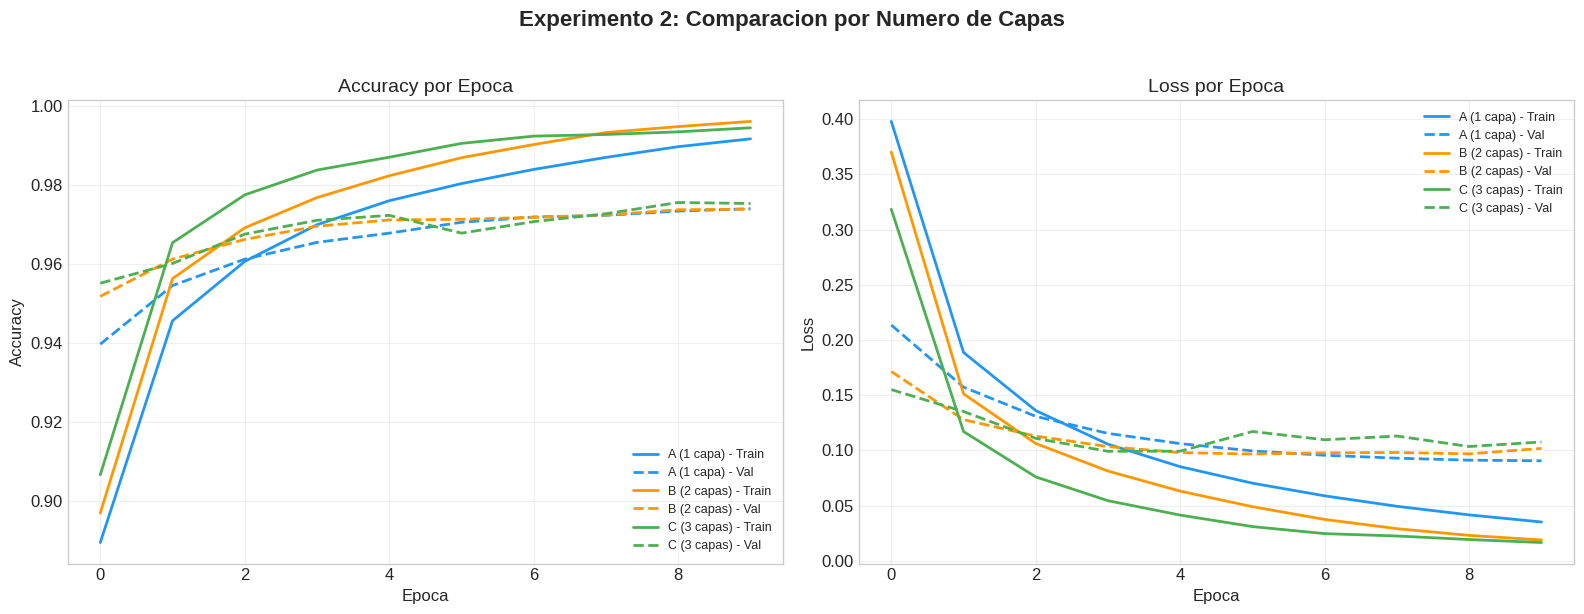

In [19]:
# Graficar las curvas de entrenamiento de los tres modelos superpuestas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores = ['#2196F3', '#FF9800', '#4CAF50']  # Azul, Naranja, Verde
nombres = ['A (1 capa)', 'B (2 capas)', 'C (3 capas)']
historiales = [hist_A, hist_B, hist_C]

for i, (hist, nombre, color) in enumerate(zip(historiales, nombres, colores)):
    # Accuracy
    axes[0].plot(hist.history['accuracy'], label=f'{nombre} - Train', color=color, linewidth=2)
    axes[0].plot(hist.history['val_accuracy'], label=f'{nombre} - Val', color=color, linewidth=2, linestyle='--')

    # Loss
    axes[1].plot(hist.history['loss'], label=f'{nombre} - Train', color=color, linewidth=2)
    axes[1].plot(hist.history['val_loss'], label=f'{nombre} - Val', color=color, linewidth=2, linestyle='--')

axes[0].set_title('Accuracy por Epoca', fontsize=14)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Loss por Epoca', fontsize=14)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Experimento 2: Comparacion por Numero de Capas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [20]:

# ============================================================
# EXPERIMENTO 3: Efecto del numero de neuronas por capa
# ============================================================

configuraciones = [
    ([32, 16], 'Pequeno_32_16'),
    ([64, 32], 'Mediano_64_32'),
    ([128, 64], 'Grande_128_64'),
    ([512, 256], 'MuyGrande_512_256')
]

resultados_exp3 = []

for config, nombre in configuraciones:
    print(f"Entrenando modelo {nombre}...")
    modelo, hist, tiempo = crear_y_entrenar_modelo(config, nombre)
    loss, acc = modelo.evaluate(x_test, y_test, verbose=0)
    params = modelo.count_params()
    resultados_exp3.append({
        'nombre': nombre,
        'config': config,
        'accuracy': acc,
        'loss': loss,
        'params': params,
        'tiempo': tiempo,
        'historial': hist
    })
    print(f"  Accuracy: {acc:.4f} | Params: {params:,} | Tiempo: {tiempo:.1f}s")

print("\nTodos los modelos entrenados!")

Entrenando modelo Pequeno_32_16...
  Accuracy: 0.9599 | Params: 25,818 | Tiempo: 14.6s
Entrenando modelo Mediano_64_32...
  Accuracy: 0.9696 | Params: 52,650 | Tiempo: 15.6s
Entrenando modelo Grande_128_64...
  Accuracy: 0.9768 | Params: 109,386 | Tiempo: 15.5s
Entrenando modelo MuyGrande_512_256...
  Accuracy: 0.9776 | Params: 535,818 | Tiempo: 14.4s

Todos los modelos entrenados!


In [21]:
# Tabla comparativa del Experimento 3
print("="*80)
print("COMPARACION DE MODELOS - Experimento 3: Numero de Neuronas")
print("="*80)
print(f"{'Modelo':<25} {'Neuronas':<15} {'Parametros':<15} {'Accuracy':<12} {'Tiempo':<10}")
print("-"*80)
for r in resultados_exp3:
    print(f"{r['nombre']:<25} {str(r['config']):<15} {r['params']:<15,} {r['accuracy']:<12.4f} {r['tiempo']:<10.1f}s")
print("="*80)

COMPARACION DE MODELOS - Experimento 3: Numero de Neuronas
Modelo                    Neuronas        Parametros      Accuracy     Tiempo    
--------------------------------------------------------------------------------
Pequeno_32_16             [32, 16]        25,818          0.9599       14.6      s
Mediano_64_32             [64, 32]        52,650          0.9696       15.6      s
Grande_128_64             [128, 64]       109,386         0.9768       15.5      s
MuyGrande_512_256         [512, 256]      535,818         0.9776       14.4      s


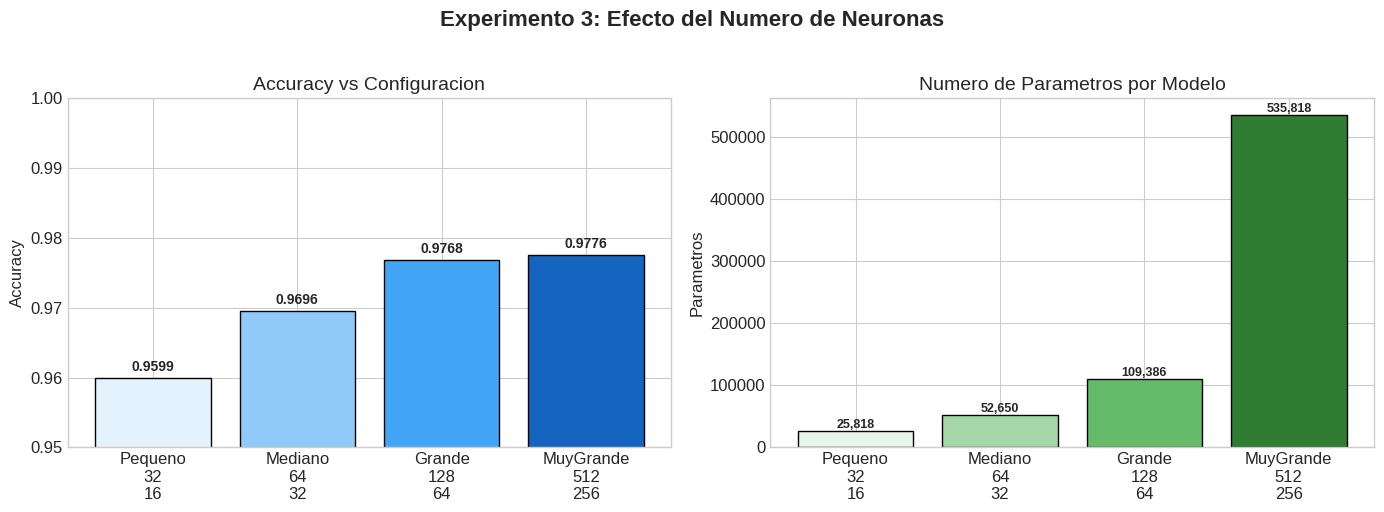

In [22]:
# Visualizacion: Accuracy vs Numero de parametros
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

params_list = [r['params'] for r in resultados_exp3]
acc_list = [r['accuracy'] for r in resultados_exp3]
tiempo_list = [r['tiempo'] for r in resultados_exp3]
nombres_list = [r['nombre'].replace('_', '\n') for r in resultados_exp3]

# Accuracy vs Parametros
axes[0].bar(nombres_list, acc_list, color=['#E3F2FD', '#90CAF9', '#42A5F5', '#1565C0'], edgecolor='black')
axes[0].set_title('Accuracy vs Configuracion', fontsize=14)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.95, 1.0)
for i, (nombre, acc) in enumerate(zip(nombres_list, acc_list)):
    axes[0].text(i, acc + 0.001, f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')

# Parametros vs Tiempo
axes[1].bar(nombres_list, params_list, color=['#E8F5E9', '#A5D6A7', '#66BB6A', '#2E7D32'], edgecolor='black')
axes[1].set_title('Numero de Parametros por Modelo', fontsize=14)
axes[1].set_ylabel('Parametros')
for i, (nombre, p) in enumerate(zip(nombres_list, params_list)):
    axes[1].text(i, p + 5000, f'{p:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Experimento 3: Efecto del Numero de Neuronas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:

# ============================================================
# EXPERIMENTO 4: Efecto del numero de epocas
# ============================================================

# Entrenaremos un unico modelo por 50 epocas y analizaremos
# el comportamiento en distintos puntos.

print("Entrenando modelo con 50 epocas (esto puede tardar un poco)...")
print("="*60)

modelo_epocas = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Modelo_Epocas')

modelo_epocas.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historial_epocas = modelo_epocas.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\nEntrenamiento completado!")

Entrenando modelo con 50 epocas (esto puede tardar un poco)...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8087 - loss: 0.6668 - val_accuracy: 0.9503 - val_loss: 0.1736
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9512 - loss: 0.1643 - val_accuracy: 0.9624 - val_loss: 0.1301
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9668 - loss: 0.1113 - val_accuracy: 0.9664 - val_loss: 0.1125
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9750 - loss: 0.0844 - val_accuracy: 0.9697 - val_loss: 0.1041
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0665 - val_accuracy: 0.9696 - val_loss: 0.1015
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9847 - loss: 0.0529 - val_accuracy: 0.9696 - val_loss: 0.1022
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9888 - loss: 0.0410 - val_accuracy: 0.9683 - val_loss: 0.1062
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2

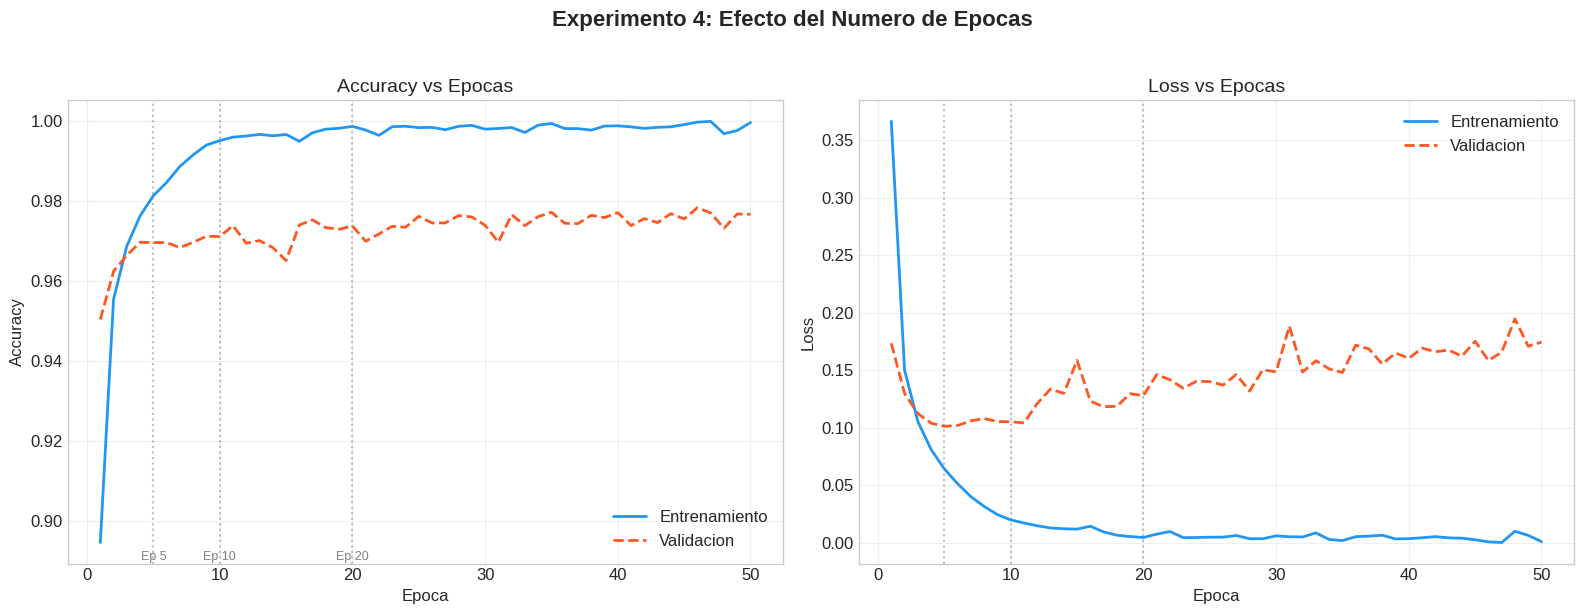

In [24]:
# Graficar el comportamiento a lo largo de las 50 epocas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epocas = range(1, 51)

# Accuracy
axes[0].plot(epocas, historial_epocas.history['accuracy'], label='Entrenamiento', linewidth=2, color='#2196F3')
axes[0].plot(epocas, historial_epocas.history['val_accuracy'], label='Validacion', linewidth=2, color='#FF5722', linestyle='--')
axes[0].set_title('Accuracy vs Epocas', fontsize=14)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Marcar puntos de referencia en las epocas 5, 10, 20
for ep in [5, 10, 20]:
    axes[0].axvline(x=ep, color='gray', linestyle=':', alpha=0.5)
    axes[0].text(ep, axes[0].get_ylim()[0] + 0.001, f'Ep {ep}', ha='center', fontsize=9, color='gray')

# Loss
axes[1].plot(epocas, historial_epocas.history['loss'], label='Entrenamiento', linewidth=2, color='#2196F3')
axes[1].plot(epocas, historial_epocas.history['val_loss'], label='Validacion', linewidth=2, color='#FF5722', linestyle='--')
axes[1].set_title('Loss vs Epocas', fontsize=14)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

for ep in [5, 10, 20]:
    axes[1].axvline(x=ep, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Experimento 4: Efecto del Numero de Epocas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Mostrar accuracy y loss en puntos clave
print("="*70)
print("RENDIMIENTO EN DIFERENTES EPOCAS")
print("="*70)
print(f"{'Epoca':<10} {'Train Acc':<15} {'Val Acc':<15} {'Train Loss':<15} {'Val Loss':<15}")
print("-"*70)

for ep in [4, 9, 19, 49]:  # Indices 0-based para epocas 5, 10, 20, 50
    t_acc = historial_epocas.history['accuracy'][ep]
    v_acc = historial_epocas.history['val_accuracy'][ep]
    t_loss = historial_epocas.history['loss'][ep]
    v_loss = historial_epocas.history['val_loss'][ep]
    print(f"{ep+1:<10} {t_acc:<15.4f} {v_acc:<15.4f} {t_loss:<15.4f} {v_loss:<15.4f}")

print("="*70)

# Detectar posible overfitting
# Overfitting: train_acc sube pero val_acc se estanca o baja
#              train_loss baja pero val_loss sube
val_losses = historial_epocas.history['val_loss']
mejor_epoca = np.argmin(val_losses) + 1
print(f"\nMejor epoca segun val_loss: Epoca {mejor_epoca}")
print(f"Val Loss en epoca {mejor_epoca}: {val_losses[mejor_epoca-1]:.4f}")
print(f"Val Loss en epoca 50: {val_losses[-1]:.4f}")

if val_losses[-1] > val_losses[mejor_epoca-1] * 1.05:
    print("\n** ALERTA: Se detecta posible overfitting. **")
    print("La perdida de validacion aumento despues de su mejor punto.")
else:
    print("\nNo se detecta overfitting significativo.")

RENDIMIENTO EN DIFERENTES EPOCAS
Epoca      Train Acc       Val Acc         Train Loss      Val Loss       
----------------------------------------------------------------------
5          0.9813          0.9696          0.0644          0.1015         
10         0.9951          0.9711          0.0201          0.1054         
20         0.9987          0.9737          0.0048          0.1282         
50         0.9996          0.9767          0.0012          0.1747         

Mejor epoca segun val_loss: Epoca 5
Val Loss en epoca 5: 0.1015
Val Loss en epoca 50: 0.1747

** ALERTA: Se detecta posible overfitting. **
La perdida de validacion aumento despues de su mejor punto.


In [26]:
# ============================================================
# EXPERIMENTO 5: Visualizacion de predicciones
# ============================================================

# Usaremos el mejor modelo del Experimento 2 (modelo_B con 2 capas)
# para hacer predicciones sobre el conjunto de prueba.

# Obtener predicciones
predicciones = modelo_B.predict(x_test, verbose=0)

# predicciones tiene forma (10000, 10): 10 probabilidades por imagen
# Tomamos la clase con mayor probabilidad
clases_predichas = np.argmax(predicciones, axis=1)
clases_reales = y_test_raw  # Las etiquetas originales (no one-hot)

print(f"Forma de las predicciones: {predicciones.shape}")
print(f"\nEjemplo de prediccion para la primera imagen:")
print(f"  Probabilidades: {np.round(predicciones[0], 4)}")
print(f"  Clase predicha: {clases_predichas[0]}")
print(f"  Clase real:     {clases_reales[0]}")

Forma de las predicciones: (10000, 10)

Ejemplo de prediccion para la primera imagen:
  Probabilidades: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
  Clase predicha: 7
  Clase real:     7


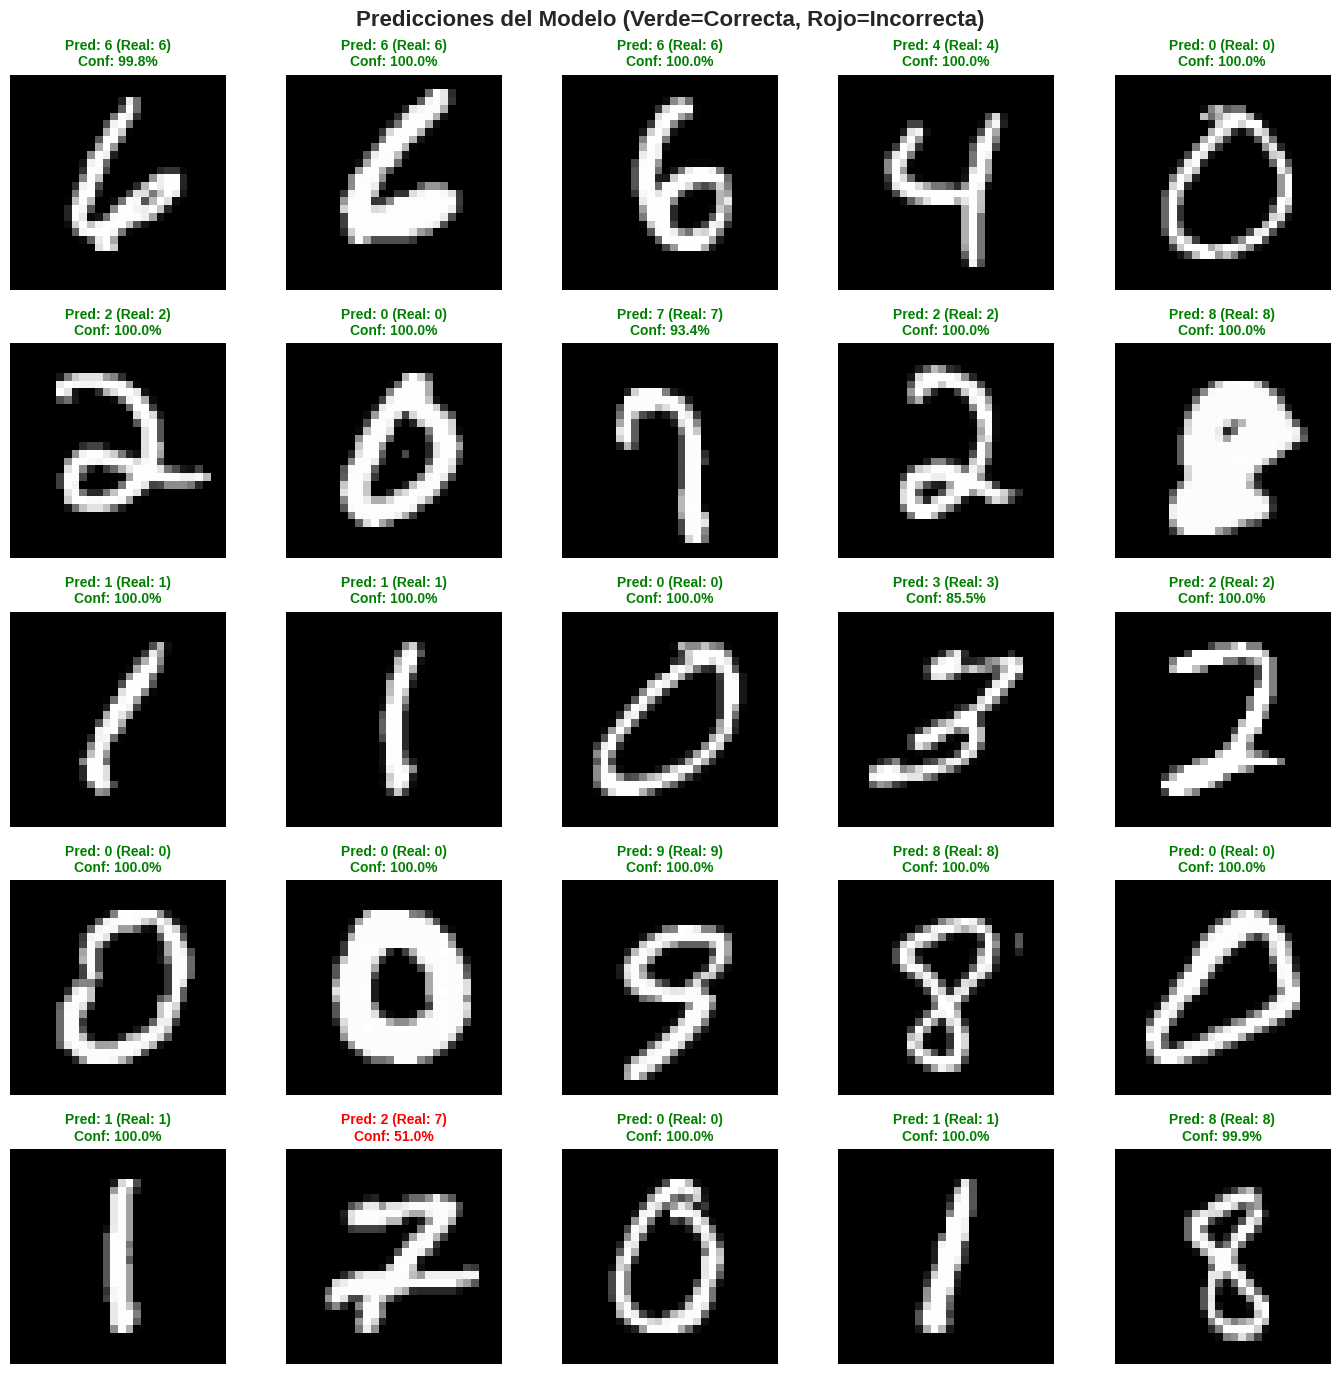

In [27]:
# --- Visualizar 25 predicciones ---
# Verde = prediccion correcta, Rojo = prediccion incorrecta

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
fig.suptitle('Predicciones del Modelo (Verde=Correcta, Rojo=Incorrecta)',
             fontsize=16, fontweight='bold')

# Seleccionar 25 indices aleatorios
indices = np.random.choice(len(x_test), 25, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    imagen = x_test_raw[idx]  # Imagen original sin normalizar para visualizacion
    pred = clases_predichas[idx]
    real = clases_reales[idx]
    confianza = predicciones[idx][pred] * 100  # Probabilidad de la prediccion

    ax.imshow(imagen, cmap='gray')

    # Color del titulo segun si es correcta o no
    if pred == real:
        color = 'green'
        titulo = f'Pred: {pred} (Real: {real})\nConf: {confianza:.1f}%'
    else:
        color = 'red'
        titulo = f'Pred: {pred} (Real: {real})\nConf: {confianza:.1f}%'

    ax.set_title(titulo, fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

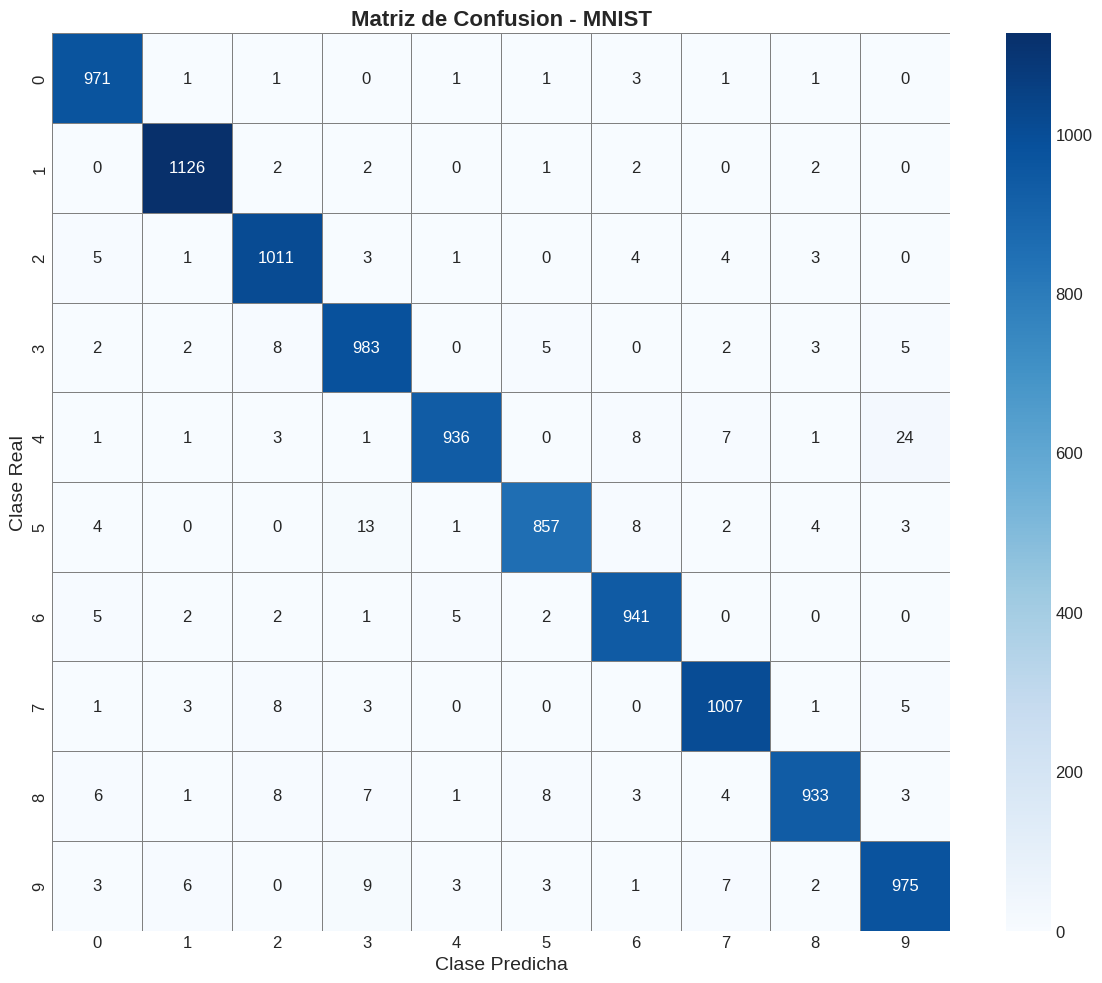

In [28]:
# --- Matriz de Confusion ---
# La matriz de confusion muestra cuantas veces cada clase fue predicha
# como cada otra clase. Es una herramienta fundamental para entender
# los errores del modelo.

cm = confusion_matrix(clases_reales, clases_predichas)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusion - MNIST', fontsize=16, fontweight='bold')
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.tight_layout()
plt.show()

# Interpretacion:
# - Los valores en la diagonal son las predicciones correctas
# - Los valores fuera de la diagonal son los errores
# - Fila i, Columna j: cuantas veces el digito i fue predicho como j

In [29]:
# --- Reporte de clasificacion ---
# Muestra precision, recall y f1-score por cada clase

print("="*60)
print("REPORTE DE CLASIFICACION DETALLADO")
print("="*60)
print(classification_report(clases_reales, clases_predichas,
                            target_names=[f'Digito {i}' for i in range(10)]))

REPORTE DE CLASIFICACION DETALLADO
              precision    recall  f1-score   support

    Digito 0       0.97      0.99      0.98       980
    Digito 1       0.99      0.99      0.99      1135
    Digito 2       0.97      0.98      0.97      1032
    Digito 3       0.96      0.97      0.97      1010
    Digito 4       0.99      0.95      0.97       982
    Digito 5       0.98      0.96      0.97       892
    Digito 6       0.97      0.98      0.98       958
    Digito 7       0.97      0.98      0.98      1028
    Digito 8       0.98      0.96      0.97       974
    Digito 9       0.96      0.97      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [30]:
# --- Encontrar los errores mas comunes ---
# Veamos cuales son las confusiones mas frecuentes

# Poner la diagonal en 0 para ver solo errores
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)

# Encontrar las 5 confusiones mas comunes
print("\nTOP 5 CONFUSIONES MAS FRECUENTES:")
print("-"*40)
for _ in range(5):
    i, j = np.unravel_index(cm_errores.argmax(), cm_errores.shape)
    print(f"  Digito {i} confundido con {j}: {cm_errores[i, j]} veces")
    cm_errores[i, j] = 0  # Poner en 0 para encontrar el siguiente


TOP 5 CONFUSIONES MAS FRECUENTES:
----------------------------------------
  Digito 4 confundido con 9: 24 veces
  Digito 5 confundido con 3: 13 veces
  Digito 9 confundido con 3: 9 veces
  Digito 3 confundido con 2: 8 veces
  Digito 4 confundido con 6: 8 veces


In [31]:
# ============================================================
# EXPERIMENTO 6: API Functional de Keras
# ============================================================

# --- API Sequential (lo que ya conocemos) ---
# modelo_seq = keras.Sequential([
#     layers.Dense(128, activation='relu', input_shape=(784,)),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])

# --- API Functional (nueva forma) ---
# En la API Functional, definimos cada capa como una funcion
# que toma como entrada la salida de la capa anterior.

# Paso 1: Definir la entrada
entrada = keras.Input(shape=(784,), name='entrada')

# Paso 2: Definir las capas ocultas como funciones
# Nota: cada capa recibe la salida de la anterior como argumento
x = layers.Dense(128, activation='relu', name='capa_oculta_1')(entrada)
x = layers.Dense(64, activation='relu', name='capa_oculta_2')(x)

# Paso 3: Definir la capa de salida
salida = layers.Dense(10, activation='softmax', name='capa_salida')(x)

# Paso 4: Crear el modelo especificando entrada y salida
modelo_functional = keras.Model(inputs=entrada, outputs=salida, name='Modelo_Functional')

# Ver el resumen
modelo_functional.summary()

print("\nEl modelo se ve identico al Sequential, pero la API Functional")
print("permite crear arquitecturas mucho mas complejas en el futuro.")

Model: "Modelo_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada (InputLayer)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_1 (Dense)           │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


El modelo se ve identico al Sequential, pero la API Functional
permite crear arquitecturas mucho mas complejas en el futuro.


In [32]:
# Compilar y entrenar el modelo Functional
modelo_functional.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Entrenando modelo con API Functional...")
historial_func = modelo_functional.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluar
loss_func, acc_func = modelo_functional.evaluate(x_test, y_test, verbose=0)
print(f"\nAccuracy en test: {acc_func:.4f} ({acc_func*100:.2f}%)")
print("\nEl resultado es similar al modelo Sequential, como esperabamos.")
print("La diferencia esta en la flexibilidad, no en el rendimiento.")

Entrenando modelo con API Functional...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8105 - loss: 0.6728 - val_accuracy: 0.9482 - val_loss: 0.1789
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9491 - loss: 0.1680 - val_accuracy: 0.9612 - val_loss: 0.1299
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9674 - loss: 0.1104 - val_accuracy: 0.9665 - val_loss: 0.1116
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9764 - loss: 0.0827 - val_accuracy: 0.9680 - val_loss: 0.1016
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9816 - loss: 0.0650 - val_accuracy: 0.9685 - val_loss: 0.1006
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0515 - val_accuracy: 0.9686 - val_loss: 0.1006
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0403 - val_accuracy: 0.9700 - val_loss: 0.0984
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 

In [33]:
# --- Ejemplo avanzado: Modelo con multiples salidas (solo demostrativo) ---
# Este ejemplo muestra por que la API Functional es poderosa.
# Imaginemos que queremos predecir:
#   1. El digito (0-9)
#   2. Si el digito es par o impar (binario)

# Con Sequential esto NO es posible. Con Functional SI:

entrada_demo = keras.Input(shape=(784,), name='entrada_demo')
x_demo = layers.Dense(128, activation='relu', name='compartida_1')(entrada_demo)
x_demo = layers.Dense(64, activation='relu', name='compartida_2')(x_demo)

# Salida 1: Clasificacion del digito (10 clases)
salida_digito = layers.Dense(10, activation='softmax', name='salida_digito')(x_demo)

# Salida 2: Par o impar (2 clases)
salida_paridad = layers.Dense(2, activation='softmax', name='salida_paridad')(x_demo)

modelo_multi = keras.Model(
    inputs=entrada_demo,
    outputs=[salida_digito, salida_paridad],
    name='Modelo_MultiSalida'
)

modelo_multi.summary()

print("\nEste modelo tiene DOS salidas! Esto es imposible con Sequential.")
print("En guias futuras veremos arquitecturas mas complejas usando la API Functional.")

Model: "Modelo_MultiSalida"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_demo        │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ compartida_1        │ (None, 128)       │    100,480 │ entrada_demo[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ compartida_2        │ (None, 64)        │      8,256 │ compartida_1[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_digito       │ (None, 10)        │        650 │ compartida_2[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_paridad      │ (None, 2)         │        130 │ compartida_2[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 109,516 (427.80 KB)

 Trainable params: 109,516 (427.80 KB)

 Non-trainable params: 0 (0.00 B)


Este modelo tiene DOS salidas! Esto es imposible con Sequential.
En guias futuras veremos arquitecturas mas complejas usando la API Functional.


In [34]:
# ============================================================
# RETO EXTRA: Fashion-MNIST
# ============================================================

# Nombres de las clases de Fashion-MNIST (para visualizacion)
nombres_clases_fashion = [
    'Camiseta', 'Pantalon', 'Jersey', 'Vestido', 'Abrigo',  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion-MNIST cargado!
Entrenamiento: (60000, 28, 28)
Prueba: (10000, 28, 28)


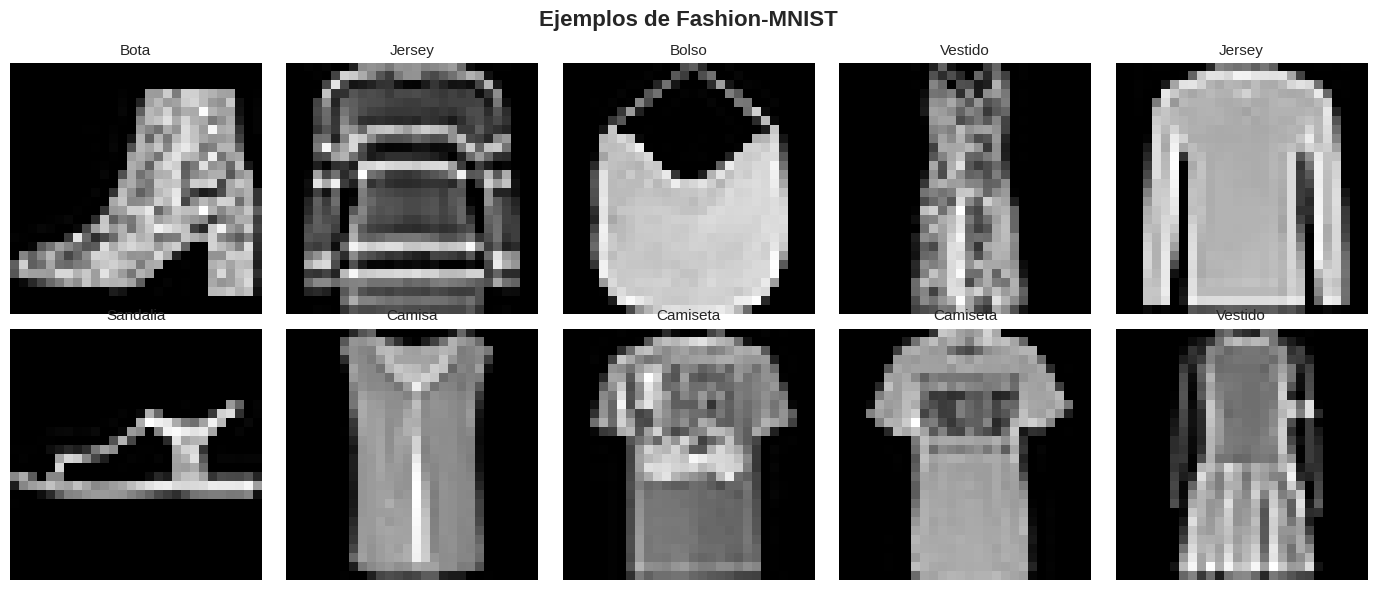

In [35]:
# --- Paso 1: Cargar los datos ---
(x_train_f, y_train_f), (x_test_f, y_test_f) = keras.datasets.fashion_mnist.load_data()

print(f"Fashion-MNIST cargado!")
print(f"Entrenamiento: {x_train_f.shape}")
print(f"Prueba: {x_test_f.shape}")

# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Ejemplos de Fashion-MNIST', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_train_f))
    ax.imshow(x_train_f[idx], cmap='gray')
    ax.set_title(nombres_clases_fashion[y_train_f[idx]], fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [36]:
# --- Paso 2: Preprocesamiento ---
x_train_fashion = x_train_f.astype('float32') / 255.0
x_test_fashion = x_test_f.astype('float32') / 255.0

x_train_fashion = x_train_fashion.reshape(-1, 784)
x_test_fashion = x_test_fashion.reshape(-1, 784)

num_clases = 10
y_train_fashion = to_categorical(y_train_f, num_clases)
y_test_fashion = to_categorical(y_test_f, num_clases)

print("Preprocesamiento completado.")
print(f"Forma de x_train_fashion: {x_train_fashion.shape}")
print(f"Forma de y_train_fashion: {y_train_fashion.shape}")

Preprocesamiento completado.
Forma de x_train_fashion: (60000, 784)
Forma de y_train_fashion: (60000, 10)


In [37]:
# --- Paso 3: Diseñar tu red neuronal ---

modelo_fashion = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,), name='capa_oculta_1'),
    layers.Dense(128, activation='relu', name='capa_oculta_2'),
    layers.Dense(10, activation='softmax', name='capa_salida')
], name='Modelo_Fashion_MNIST')

modelo_fashion.summary()

Model: "Modelo_Fashion_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# --- Paso 4: Compilar y entrenar ---

modelo_fashion.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando entrenamiento...")
historial_fashion = modelo_fashion.fit(
    x_train_fashion, y_train_fashion,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7523 - loss: 0.7134 - val_accuracy: 0.8552 - val_loss: 0.4214
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.3925 - val_accuracy: 0.8637 - val_loss: 0.3808
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8758 - loss: 0.3453 - val_accuracy: 0.8703 - val_loss: 0.3548
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8850 - loss: 0.3147 - val_accuracy: 0.8782 - val_loss: 0.3369
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8928 - loss: 0.2924 - val_accuracy: 0.8788 - val_loss: 0.3298
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.2755 - val_accuracy: 0.8779 - val_loss: 0.3301
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9040 - loss: 0.2609 - val_accuracy: 0.8820 - val_loss: 0.3208
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9087 - loss


Accuracy final en el conjunto de prueba: 87.30%


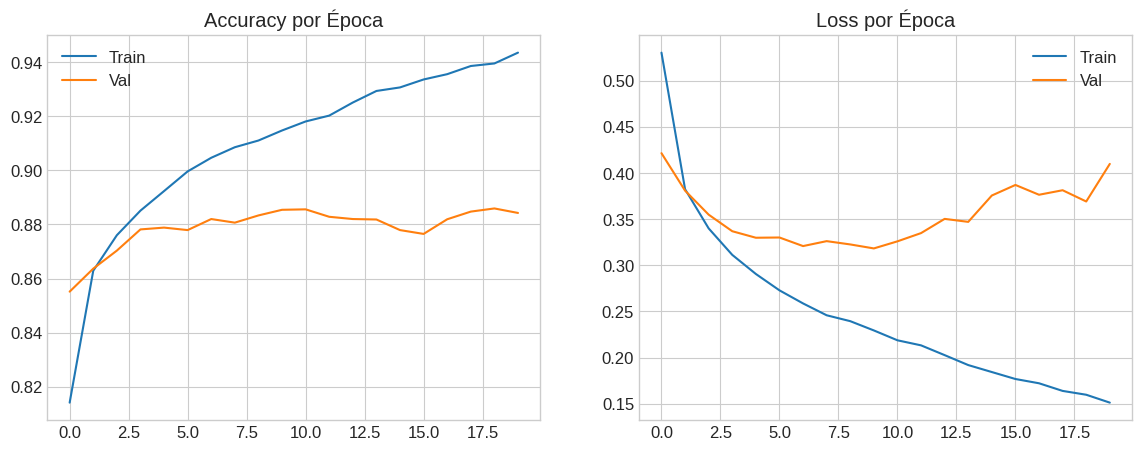

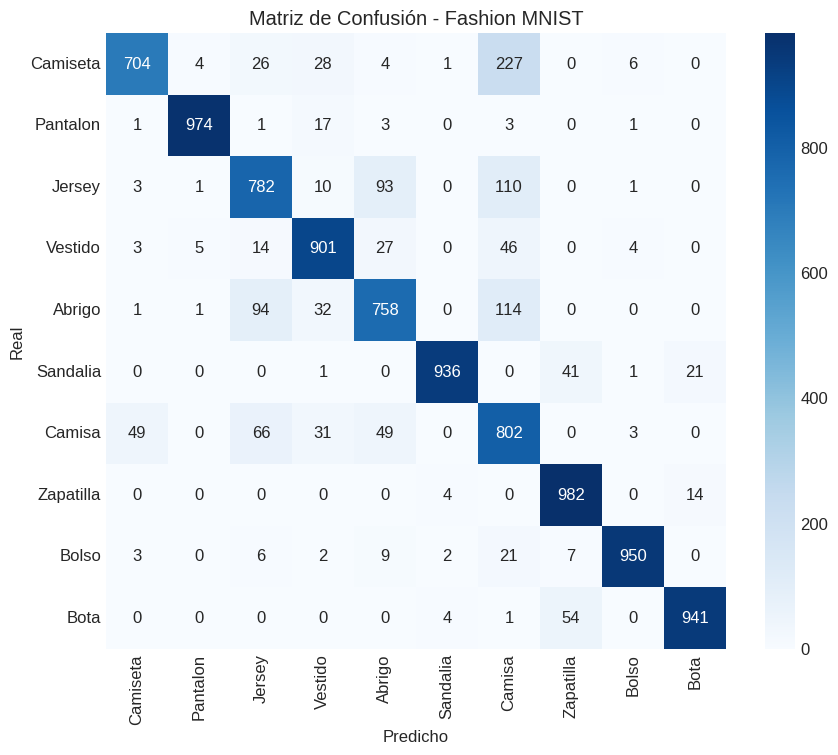

In [39]:
# --- Paso 5: Evaluar y mostrar resultados ---

loss_f, acc_f = modelo_fashion.evaluate(x_test_fashion, y_test_fashion, verbose=0)
print(f"\nAccuracy final en el conjunto de prueba: {acc_f*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historial_fashion.history['accuracy'], label='Train')
axes[0].plot(historial_fashion.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy por Época')
axes[0].legend()

axes[1].plot(historial_fashion.history['loss'], label='Train')
axes[1].plot(historial_fashion.history['val_loss'], label='Val')
axes[1].set_title('Loss por Época')
axes[1].legend()
plt.show()

predicciones_f = modelo_fashion.predict(x_test_fashion, verbose=0)
clases_pred_f = np.argmax(predicciones_f, axis=1)

cm_f = confusion_matrix(y_test_f, clases_pred_f)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases_fashion,
            yticklabels=nombres_clases_fashion)
plt.title('Matriz de Confusión - Fashion MNIST')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()